In [24]:
#Importar vendas.csv
from google.colab import files

uploaded = files.upload()

Saving vendas.csv to vendas (2).csv


In [25]:
#RF02 – Inspecionar e Descrever os Dados
import pandas as pd

df = pd.read_csv("vendas.csv")

def data_inspect(df: pd.DataFrame):
    """Exibe as informacoes estruturais do DataFrame."""
    print("\n=== INSPECAO INICIAL DO DATASET ===")
    print(
        f"Shape: {df.shape}, sendo {df.shape[0]} linhas e {df.shape[1]} colunas"
    )
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    return df

data_inspect(df)



=== INSPECAO INICIAL DO DATASET ===
Shape: (200, 8), sendo 200 linhas e 8 colunas

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade        10
preco_unitario     4
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-03-23  Cliente_045    Tablet     Celulares  Centro-Oeste   
3         4  2025-11-0

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14
...,...,...,...,...,...,...,...,...
195,196,2025-06-04,CLIENTE-038,Monitor,Computadores,Centro-Oeste,5.0,NaN
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3.0,1748.92
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3.0,2185.60
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4.0,368.94


In [26]:
#RF03 – Limpar e Tratar os Dados
#re = lib de expressoes regulares
import re

def normalize_client_id(value):
    """
    Padroniza o identificador do cliente para Cliente_NNN
    """
    value = str(value).strip()

    # Limpa string mantendo somente letras e numeros
    value = re.sub(r"[^A-Za-z0-9]", "", value)

    # Pega o id numerico do cliente
    number = re.sub(r"[^0-9]", "", value)

    return f"Cliente_{int(number):03d}"

def data_clean(df: pd.DataFrame):
    initial_data_count = len(df)

    for column in ["cliente", "produto", "categoria", "regiao"]:
        #remove espacos inicio/fim da string
        df[column] = df[column].str.strip()

    #converte para data alterando data invalida para NaT
    df["data_venda"] = pd.to_datetime(
        df["data_venda"],
        errors="coerce"
    )

    invalid_dates_count: int = df["data_venda"].isna().sum()

    #remove datas invalidas
    df = df.dropna(subset=["data_venda"])

    #contagem de nulos em quantidade e preco_unitario para relatorio
    critical_null_count = df[
        ["quantidade", "preco_unitario"]
    ].isnull().any(axis=1).sum()

    #descartar nulos em quantidade e preco_unitario
    df = df.dropna(
        subset=["quantidade", "preco_unitario"]
    )

    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    #limpeza de texto com expressao regular
    df["cliente"] = df["cliente"].apply(
        lambda s: re.sub(r"[^A-Za-z0-9_]", "", str(s).strip())
    )

    # Validar padrao Cliente_NNN - IGNORECASE = ignorando maiusc/munisc
    valid_client = re.compile(
        r"^Cliente_\d{3}$",
        flags=re.IGNORECASE
    )

    #informa se o cliente esta fora do padrao com true ou false
    df["cliente_fora_padrao"] = ~df["cliente"].apply(
        lambda x: bool(valid_client.match(x))
    )

    #ajusta o padrao depois de contabilizar clientes fora do padrao
    df["cliente"] = df["cliente"].apply(normalize_client_id)

    final_data_count = len(df)

    report = {
        "initial_data_count": initial_data_count,
        "invalid_dates_count": int(invalid_dates_count),
        "critical_null_count": int(critical_null_count),
        "final_data_count": final_data_count
    }

    print("\n=== RELATORIO DE LIMPEZA ===")
    print(f"Registros iniciais: {initial_data_count}")
    print(f"Datas inválidas removidas: {invalid_dates_count}")
    print(f"Nulos críticos removidos: {critical_null_count}")
    print(f"Registros finais: {final_data_count}")
    print(f"Registros removidos: {(initial_data_count - final_data_count)}")

    return df, report

cleaned_df, clean_report = data_clean(df)

display(cleaned_df)


=== RELATORIO DE LIMPEZA ===
Registros iniciais: 200
Datas inválidas removidas: 4
Nulos críticos removidos: 13
Registros finais: 183
Registros removidos: 17


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,cliente_fora_padrao
0,1,2025-05-21,Cliente_016,Mouse,Perifericos,Sudeste,2,102.90,True
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1,1939.76,False
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6,3864.87,False
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10,2008.14,False
5,6,2025-08-21,Cliente_041,Headset,Perifericos,Sudeste,2,337.41,False
...,...,...,...,...,...,...,...,...,...
194,195,2025-12-09,Cliente_007,Teclado,Perifericos,Sul,6,219.01,False
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3,1748.92,False
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3,2185.60,False
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4,368.94,False


In [27]:
#RF04 – Criar Colunas Derivadas com Transformações Condicionais
import numpy as np

def months_name_br():
    """
    Dicionario com os meses em pt-br
    """
    return {
        1: "Janeiro",
        2: "Fevereiro",
        3: "Março",
        4: "Abril",
        5: "Maio",
        6: "Junho",
        7: "Julho",
        8: "Agosto",
        9: "Setembro",
        10: "Outubro",
        11: "Novembro",
        12: "Dezembro"
    }

def get_revenue_conditions(df: pd.DataFrame):
    return [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) &
        (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]

def get_revenue_range():
    return [
        "Baixo Valor",
        "Medio Valor",
        "Alto Valor"
    ]

def revenue_and_date_columns(df: pd.DataFrame):
    df["receita_total"] = (
        df["quantidade"] * df["preco_unitario"]
    )

    df["mes"] = df["data_venda"].dt.month

    df["mes_nome"] = df["mes"].map(months_name_br())

    #cast de integer para string para concatenar
    df["trimestre"] = (
        "Q" + df["data_venda"].dt.quarter.astype(str)
    )

    df["ano"] = df["data_venda"].dt.year

    df["faixa_receita_item"] = np.select(
        get_revenue_conditions(df),
        get_revenue_range(),
        default="Nao Classificado"
    )

    return df

revenue_and_date_columns(cleaned_df)

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,cliente_fora_padrao,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item
0,1,2025-05-21,Cliente_016,Mouse,Perifericos,Sudeste,2,102.90,True,205.80,5,Maio,Q2,2025,Baixo Valor
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1,1939.76,False,1939.76,3,Março,Q1,2025,Medio Valor
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6,3864.87,False,23189.22,11,Novembro,Q4,2025,Alto Valor
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10,2008.14,False,20081.40,7,Julho,Q3,2025,Alto Valor
5,6,2025-08-21,Cliente_041,Headset,Perifericos,Sudeste,2,337.41,False,674.82,8,Agosto,Q3,2025,Medio Valor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,195,2025-12-09,Cliente_007,Teclado,Perifericos,Sul,6,219.01,False,1314.06,12,Dezembro,Q4,2025,Medio Valor
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3,1748.92,False,5246.76,9,Setembro,Q3,2025,Alto Valor
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3,2185.60,False,6556.80,8,Agosto,Q3,2025,Alto Valor
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4,368.94,False,1475.76,11,Novembro,Q4,2025,Medio Valor


In [28]:
#RF05 – Calcular Métricas Agregadas com groupby

def get_revenue_by_month(df: pd.DataFrame):
    """
    Soma receita e quantidade vendida
    e conta quantas vendas aconteceram
    """
    return (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            qtd_vendas=("id_venda", "count")
        )
        .reset_index()
        .sort_values("mes")
    )

def get_top_products_by_revenue(df: pd.DataFrame):
    return (
        df.groupby("produto")["receita_total"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
            .reset_index()
    )

def get_revenue_by_category(df: pd.DataFrame):
    return (
        df.groupby("categoria")["receita_total"]
            .sum()
            .sort_values(ascending=False)
            .reset_index()
    )

def get_revenue_and_mean_ticket(df: pd.DataFrame):
    return (
        df.groupby("regiao")
            .agg(
                receita_total=("receita_total", "sum"),
                ticket_medio=("receita_total", "mean")
            )
            .reset_index()
            .round({"ticket_medio": 2})
    )


def get_metrics(df: pd.DataFrame):
    return {
        "por_mes": get_revenue_by_month(df),
        "top_produtos": get_top_products_by_revenue(df),
        "por_categoria": get_revenue_by_category(df),
        "por_regiao": get_revenue_and_mean_ticket(df)
    }

metrics = get_metrics(cleaned_df)

print("\n=== POR MES ===")
display(metrics["por_mes"])

print("\n=== TOP PRODUTOS ===")
display(metrics["top_produtos"])

print("\n=== POR CATEGORIA ===")
display(metrics["por_categoria"])

print("\n=== POR REGIAO ===")
display(metrics["por_regiao"])


=== POR MES ===


,mes,receita_total,quantidade,qtd_vendas
0,1,120866.25,92,15
1,2,73895.74,70,12
2,3,123869.23,98,18
3,4,80636.64,48,7
4,5,132080.62,104,19
5,6,106534.48,95,15
6,7,106667.30,84,14
7,8,85790.38,72,12
8,9,84081.59,89,17
9,10,110865.86,72,17



=== TOP PRODUTOS ===


,produto,receita_total
0,Notebook,374174.85
1,Tablet,335335.83
2,Smartphone,303255.94
3,Monitor,169554.67
4,Headset,48368.37



=== POR CATEGORIA ===


,categoria,receita_total
0,Celulares,638591.77
1,Computadores,543729.52
2,Perifericos,108025.01



=== POR REGIAO ===


,regiao,receita_total,ticket_medio
0,Centro-Oeste,244586.97,5688.07
1,Nordeste,366321.23,8721.93
2,Norte,299917.37,7140.89
3,Sudeste,151271.07,7203.38
4,Sul,228249.66,6521.42


In [29]:
#RF06 – Segmentar Clientes por Nível de Gasto

def get_client_level_by_spent(spent):
    if spent < 5000:
        return "Bronze"
    elif spent <= 15000:
        return "Prata"
    else:
        return "Ouro"

def clients_segment(df: pd.DataFrame):
    clients = (
        df.groupby("cliente")["receita_total"]
            .sum()
            .reset_index(name="total_gasto")
    )

    clients["total_gasto"] = clients["total_gasto"].apply(
        lambda spent: round(spent, 2)
    )

    clients["segmento"] = clients["total_gasto"].apply(
        get_client_level_by_spent
    )

    clients = clients.sort_values(
        "total_gasto",
        ascending=False
    )

    print("\n=== TOP 10 CLIENTES ===")
    display(clients.head(10))

    print("\n=== DISTRIBUIÇÃO POR SEGMENTO ===")
    display(clients["segmento"].value_counts())

    return clients

segmented_clients = clients_segment(cleaned_df)


=== TOP 10 CLIENTES ===


,cliente,total_gasto,segmento
5,Cliente_006,65905.09,Ouro
35,Cliente_036,63433.04,Ouro
38,Cliente_039,59406.90,Ouro
19,Cliente_020,58459.54,Ouro
10,Cliente_011,56391.77,Ouro
33,Cliente_034,52035.60,Ouro
8,Cliente_009,50827.96,Ouro
23,Cliente_024,49146.94,Ouro
36,Cliente_037,46897.17,Ouro
18,Cliente_019,40731.05,Ouro



=== DISTRIBUIÇÃO POR SEGMENTO ===


,count
segmento,
Ouro,34
Prata,10
Bronze,6


In [30]:
#RF07 – Operações Numéricas com NumPy

def calculate_numpy_statistics(df: pd.DataFrame):
    """
    Aplica operações NumPy sobre a coluna receita_total.
    Retorna um dicionario com os valores calculados.
    """

    revenues = df["receita_total"].to_numpy()

    # Agregacoes NumPy
    revenue_mean = np.mean(revenues)
    revenue_median = np.median(revenues)
    #desvio padrao
    revenue_sd = np.std(revenues)
    revenue_sum = np.sum(revenues)
    revenue_min = np.min(revenues)
    revenue_max = np.max(revenues)

    # Broadcasting - receitas escalonadas
    staggered_revenue = (
        revenues - revenues.min()
    ) / (
        revenues.max() - revenues.min()
    )

    # Filtragem booleana
    revenue_bigger_mean = revenues[revenues > revenue_mean]

    quantity_bigger_mean = np.sum(revenues > revenue_mean)

    return {
        "media": revenue_mean,
        "mediana": revenue_median,
        "desvio_padrao": revenue_sd,
        "soma": revenue_sum,
        "minimo": revenue_min,
        "maximo": revenue_max,
        "receitas_escalonadas": staggered_revenue,
        "acima_da_media": revenue_bigger_mean,
        "quantidade_acima_media": quantity_bigger_mean
    }

numpy_results = calculate_numpy_statistics(cleaned_df)

print(f"Média: {numpy_results['media']:.2f}")
print(f"Mediana: {numpy_results['mediana']:.2f}")
print(f"Desvio padrão: {numpy_results['desvio_padrao']:.2f}")
print(f"Soma: {numpy_results['soma']:.2f}")
print(f"Mínimo: {numpy_results['minimo']:.2f}")
print(f"Máximo: {numpy_results['maximo']:.2f}")
print(
    "Quantidade acima da média:",
    numpy_results["quantidade_acima_media"]
)
#somente as 10 primeiras para nao imprimir tudo e poluir os resultados da secao
print(
    "Primeiros valores escalonados:",
    numpy_results["receitas_escalonadas"][:10]
)
print(
    "Primeiras receitas acima da média:",
    numpy_results["acima_da_media"][:10]
)

Média: 7051.07
Mediana: 3330.66
Desvio padrão: 7809.92
Soma: 1290346.30
Mínimo: 104.19
Máximo: 38833.20
Quantidade acima da média: 70
Primeiros valores escalonados: [0.00262361 0.04739522 0.59606558 0.51582031 0.01473392 0.0168734
 0.00561233 0.02132071 0.04062484 0.04613622]
Primeiras receitas acima da média: [23189.22 20081.4  15587.64 17615.97  8316.91  7982.16 22623.8  10656.1
  7079.04 10252.89]


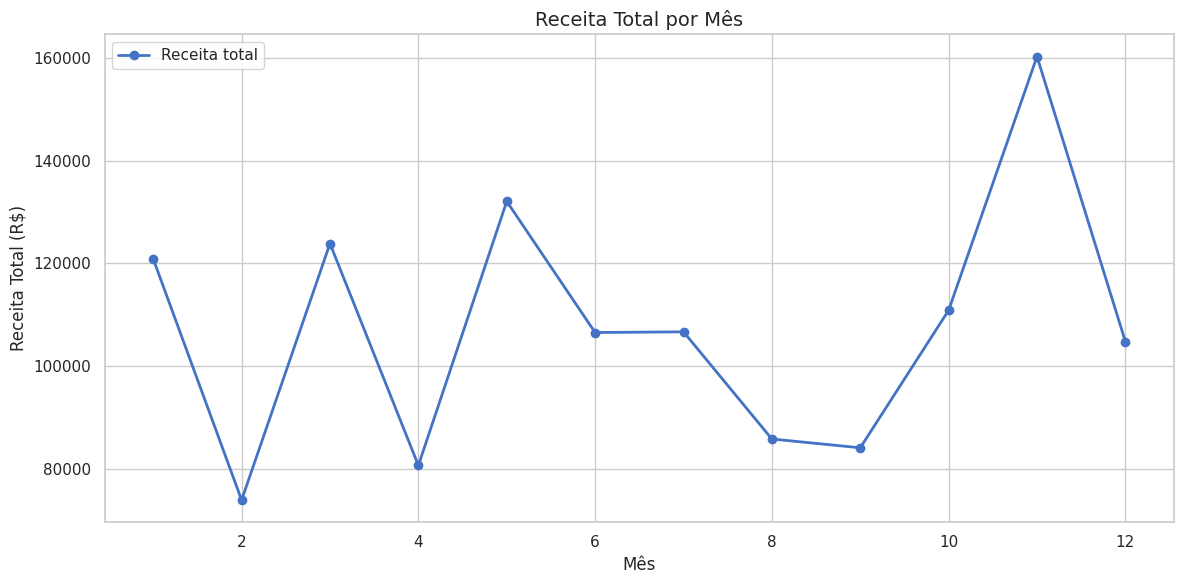

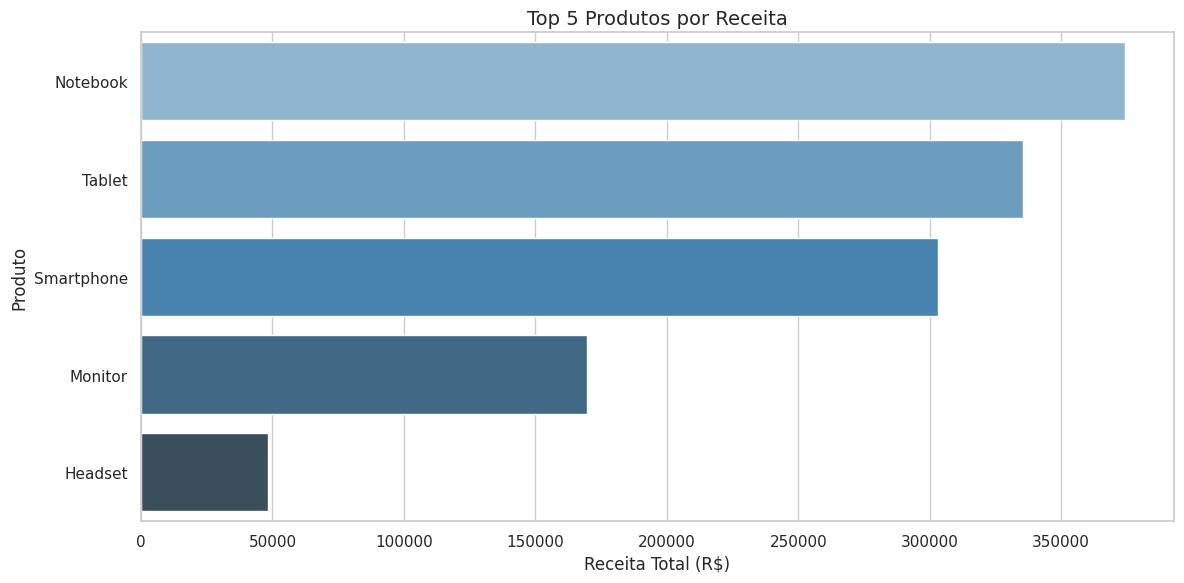

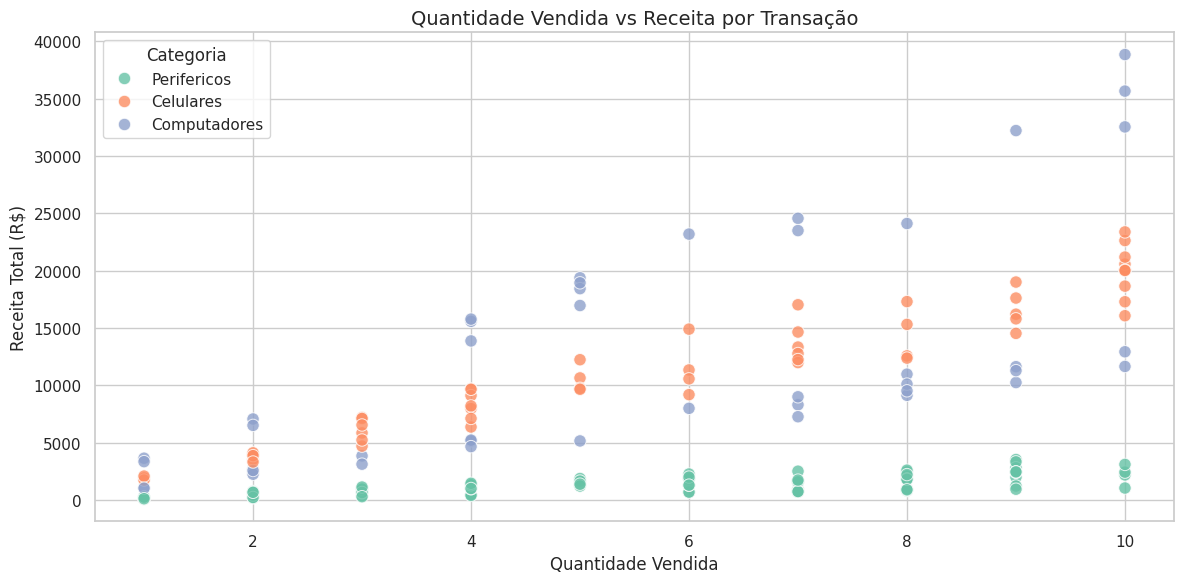

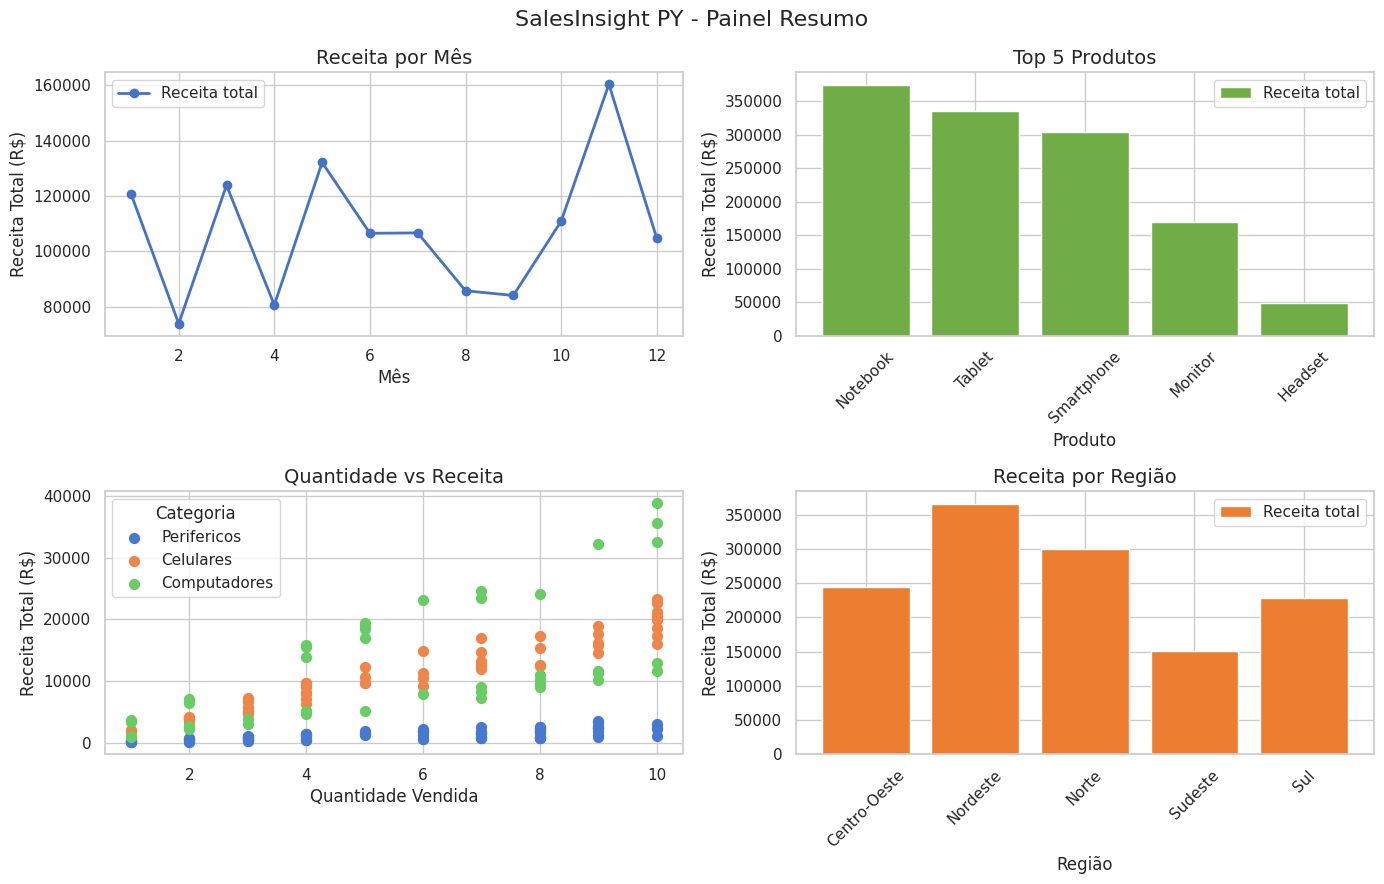

In [31]:
# RF08 – Criar Visualizações com Matplotlib e Seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import os


# ============================================================
# VISUAL CONFIGURATION
# ============================================================

sns.set_theme(
    style="whitegrid",
    palette="muted"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14

os.makedirs("outputs/graficos", exist_ok=True)


# ============================================================
# FIGURE 1 – RECEITA TOTAL POR MÊS
# ============================================================

monthly_revenue = metrics["por_mes"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_revenue["mes"],
    monthly_revenue["receita_total"],
    marker="o",
    linewidth=2,
    color="#4472C4",
    label="Receita total"
)

ax.set_title("Receita Total por Mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Receita Total (R$)")
ax.legend()

plt.tight_layout()

plt.savefig(
    "outputs/graficos/receita_por_mes.png",
    dpi=150
)

plt.show()
plt.close()


# ============================================================
# FIGURE 2 – TOP 5 PRODUTOS POR RECEITA
# ============================================================

top_products = metrics["top_produtos"]

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_products,
    y="produto",
    x="receita_total",
    hue="produto",
    palette="Blues_d",
    legend=False,
    ax=ax
)

ax.set_title("Top 5 Produtos por Receita")
ax.set_xlabel("Receita Total (R$)")
ax.set_ylabel("Produto")

plt.tight_layout()

plt.savefig(
    "outputs/graficos/top_produtos.png",
    dpi=150
)

plt.show()
plt.close()


# ============================================================
# FIGURE 3 – QUANTIDADE VS RECEITA POR TRANSAÇÃO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=cleaned_df,
    x="quantidade",
    y="receita_total",
    hue="categoria",
    palette="Set2",
    s=80,
    alpha=0.8,
    ax=ax
)

ax.set_title("Quantidade Vendida vs Receita por Transação")
ax.set_xlabel("Quantidade Vendida")
ax.set_ylabel("Receita Total (R$)")
ax.legend(title="Categoria")

plt.tight_layout()

plt.savefig(
    "outputs/graficos/quantidade_vs_receita.png",
    dpi=150
)

plt.show()
plt.close()


# ============================================================
# FIGURE 4 – PAINEL RESUMO 2x2
# ============================================================

regional_revenue = metrics["por_regiao"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)


# ------------------------------------------------------------
# 1. Receita por mês
# ------------------------------------------------------------

axes[0, 0].plot(
    monthly_revenue["mes"],
    monthly_revenue["receita_total"],
    marker="o",
    linewidth=2,
    color="#4472C4",
    label="Receita total"
)

axes[0, 0].set_title("Receita por Mês")
axes[0, 0].set_xlabel("Mês")
axes[0, 0].set_ylabel("Receita Total (R$)")
axes[0, 0].legend()


# ------------------------------------------------------------
# 2. Top produtos
# ------------------------------------------------------------

axes[0, 1].bar(
    top_products["produto"],
    top_products["receita_total"],
    color="#70AD47",
    label="Receita total"
)

axes[0, 1].set_title("Top 5 Produtos")
axes[0, 1].set_xlabel("Produto")
axes[0, 1].set_ylabel("Receita Total (R$)")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()


# ------------------------------------------------------------
# 3. Quantidade vs receita
# ------------------------------------------------------------

categories = cleaned_df["categoria"].unique()

for category in categories:

    category_data = cleaned_df[
        cleaned_df["categoria"] == category
    ]

    axes[1, 0].scatter(
        category_data["quantidade"],
        category_data["receita_total"],
        label=category,
        s=50
    )

axes[1, 0].set_title("Quantidade vs Receita")
axes[1, 0].set_xlabel("Quantidade Vendida")
axes[1, 0].set_ylabel("Receita Total (R$)")
axes[1, 0].legend(title="Categoria")


# ------------------------------------------------------------
# 4. Receita por região
# ------------------------------------------------------------

axes[1, 1].bar(
    regional_revenue["regiao"],
    regional_revenue["receita_total"],
    color="#ED7D31",
    label="Receita total"
)

axes[1, 1].set_title("Receita por Região")
axes[1, 1].set_xlabel("Região")
axes[1, 1].set_ylabel("Receita Total (R$)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

fig.suptitle(
    "SalesInsight PY - Painel Resumo",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "outputs/graficos/painel_resumo.png",
    dpi=150
)

plt.show()
plt.close()

In [32]:
# RF09 – Organizar o Código em Funções Reutilizáveis e em uma Classe


# ============================================================
# PARTE A – FUNÇÃO DE ORDEM SUPERIOR
# ============================================================

def process_column(
    df: pd.DataFrame,
    column: str,
    transformation_function,
    output_name: str = None
):
    """
    Aplica uma função de transformação a uma coluna do DataFrame.

    Demonstra o uso de uma função como argumento.
    """

    output_name = output_name or f"{column}_transformado"

    df[output_name] = df[column].apply(
        transformation_function
    )

    return df


# ============================================================
# EXEMPLO 1 – LAMBDA COM RECEITA
# ============================================================

cleaned_df = process_column(
    cleaned_df,
    "receita_total",
    lambda value: round(value / 1000, 2),
    output_name="receita_em_milhares"
)


# ============================================================
# EXEMPLO 2 – LAMBDA COM QUANTIDADE
# ============================================================

cleaned_df = process_column(
    cleaned_df,
    "quantidade",
    lambda quantity:
        "Alto Volume"
        if quantity > 5
        else "Baixo Volume",
    output_name="perfil_volume"
)


print("\n=== TRANSFORMAÇÕES COM FUNÇÃO DE ORDEM SUPERIOR ===")

display(
    cleaned_df[
        [
            "receita_total",
            "receita_em_milhares",
            "quantidade",
            "perfil_volume"
        ]
    ].head(10)
)


# ============================================================
# PARTE B – CLASSE PARA ORGANIZAR O FLUXO
# ============================================================

class SalesDataAnalyzer:
    """
    Encapsula o fluxo de análise dos dados de vendas.
    """

    def __init__(self, file_path):
        """
        Inicializa o analisador de dados de vendas.
        """

        self.file_path = file_path

        self.raw_df = None
        self.cleaned_df = None
        self.metrics = {}
        self.clients = None
        self.numpy_results = {}
        self.clean_report = {}

    def load(self):
        """
        Carrega o arquivo CSV e armazena o DataFrame bruto.
        """

        self.raw_df = pd.read_csv(
            self.file_path
        )

        print(
            f"[Analisador] "
            f"{len(self.raw_df)} registros lidos."
        )

        return self.raw_df

    def clean(self):
        """
        Limpa os dados utilizando a função de limpeza existente.
        """

        self.cleaned_df, self.clean_report = data_clean(
            self.raw_df.copy()
        )

        print(
            f"[Analisador] "
            f"{len(self.cleaned_df)} registros após limpeza."
        )

        return self.cleaned_df

    def transform(self):
        """
        Cria as colunas derivadas utilizando a função existente.
        """

        self.cleaned_df = revenue_and_date_columns(
            self.cleaned_df
        )

        return self.cleaned_df

    def analyze(self):
        """
        Calcula as métricas, segmentação de clientes
        e operações NumPy.
        """

        self.metrics = get_metrics(
            self.cleaned_df
        )

        self.clients = clients_segment(
            self.cleaned_df
        )

        self.numpy_results = calculate_numpy_statistics(
            self.cleaned_df
        )

        return {
            "metrics": self.metrics,
            "clients": self.clients,
            "numpy_results": self.numpy_results
        }

    def visualize(self):
        """
        Gera e exporta as figuras da análise.
        """

        monthly_revenue = self.metrics["por_mes"]
        top_products = self.metrics["top_produtos"]
        regional_revenue = self.metrics["por_regiao"]

        os.makedirs(
            "outputs/graficos",
            exist_ok=True
        )

        # ====================================================
        # FIGURA 1 – RECEITA POR MÊS
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(12, 6)
        )

        ax.plot(
            monthly_revenue["mes"],
            monthly_revenue["receita_total"],
            marker="o",
            linewidth=2,
            color="#4472C4",
            label="Receita total"
        )

        ax.set_title(
            "Receita Total por Mês"
        )
        ax.set_xlabel("Mês")
        ax.set_ylabel("Receita Total (R$)")
        ax.legend()

        plt.tight_layout()

        plt.savefig(
            "outputs/graficos/receita_por_mes.png",
            dpi=150
        )

        plt.show()
        plt.close()


        # ====================================================
        # FIGURA 2 – TOP 5 PRODUTOS
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(12, 6)
        )

        sns.barplot(
            data=top_products,
            y="produto",
            x="receita_total",
            hue="produto",
            palette="Blues_d",
            legend=False,
            ax=ax
        )

        ax.set_title(
            "Top 5 Produtos por Receita"
        )
        ax.set_xlabel("Receita Total (R$)")
        ax.set_ylabel("Produto")

        plt.tight_layout()

        plt.savefig(
            "outputs/graficos/top_produtos.png",
            dpi=150
        )

        plt.show()
        plt.close()


        # ====================================================
        # FIGURA 3 – QUANTIDADE VS RECEITA
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(12, 6)
        )

        sns.scatterplot(
            data=self.cleaned_df,
            x="quantidade",
            y="receita_total",
            hue="categoria",
            palette="Set2",
            s=80,
            alpha=0.8,
            ax=ax
        )

        ax.set_title(
            "Quantidade Vendida vs Receita por Transação"
        )
        ax.set_xlabel("Quantidade Vendida")
        ax.set_ylabel("Receita Total (R$)")
        ax.legend(title="Categoria")

        plt.tight_layout()

        plt.savefig(
            "outputs/graficos/quantidade_vs_receita.png",
            dpi=150
        )

        plt.show()
        plt.close()


        # ====================================================
        # FIGURA 4 – PAINEL RESUMO 2x2
        # ====================================================

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(14, 9)
        )


        # Receita por mês
        axes[0, 0].plot(
            monthly_revenue["mes"],
            monthly_revenue["receita_total"],
            marker="o",
            linewidth=2,
            color="#4472C4",
            label="Receita total"
        )

        axes[0, 0].set_title(
            "Receita por Mês"
        )
        axes[0, 0].set_xlabel("Mês")
        axes[0, 0].set_ylabel(
            "Receita Total (R$)"
        )
        axes[0, 0].legend()


        # Top produtos
        axes[0, 1].bar(
            top_products["produto"],
            top_products["receita_total"],
            color="#70AD47",
            label="Receita total"
        )

        axes[0, 1].set_title(
            "Top 5 Produtos"
        )
        axes[0, 1].set_xlabel(
            "Produto"
        )
        axes[0, 1].set_ylabel(
            "Receita Total (R$)"
        )
        axes[0, 1].tick_params(
            axis="x",
            rotation=45
        )
        axes[0, 1].legend()


        # Quantidade vs receita
        categories = (
            self.cleaned_df["categoria"]
            .unique()
        )

        for category in categories:

            category_data = self.cleaned_df[
                self.cleaned_df["categoria"] == category
            ]

            axes[1, 0].scatter(
                category_data["quantidade"],
                category_data["receita_total"],
                label=category,
                s=50
            )

        axes[1, 0].set_title(
            "Quantidade vs Receita"
        )
        axes[1, 0].set_xlabel(
            "Quantidade Vendida"
        )
        axes[1, 0].set_ylabel(
            "Receita Total (R$)"
        )
        axes[1, 0].legend(
            title="Categoria"
        )


        # Receita por região
        axes[1, 1].bar(
            regional_revenue["regiao"],
            regional_revenue["receita_total"],
            color="#ED7D31",
            label="Receita total"
        )

        axes[1, 1].set_title(
            "Receita por Região"
        )
        axes[1, 1].set_xlabel(
            "Região"
        )
        axes[1, 1].set_ylabel(
            "Receita Total (R$)"
        )
        axes[1, 1].tick_params(
            axis="x",
            rotation=45
        )
        axes[1, 1].legend()


        fig.suptitle(
            "SalesInsight PY - Painel Resumo",
            fontsize=16
        )

        plt.tight_layout()

        plt.savefig(
            "outputs/graficos/painel_resumo.png",
            dpi=150
        )

        plt.show()
        plt.close()

        print(
            "\n[Analisador] "
            "Gráficos gerados e exportados com sucesso."
        )

    def summary(self):
        """
        Exibe um resumo executivo do processamento.
        """

        print("\n=== RESUMO DA ANÁLISE ===")

        print(
            f"Registros brutos: "
            f"{len(self.raw_df)}"
        )

        print(
            f"Registros após limpeza: "
            f"{len(self.cleaned_df)}"
        )


        print(
            f"Registros removidos: "
            f"{self.clean_report['initial_data_count'] - self.clean_report['final_data_count']}"
        )

        print(
            f"\nReceita total: "
            f"R$ {self.numpy_results['soma']:.2f}"
        )

        print(
            f"Receita média por transação: "
            f"R$ {self.numpy_results['media']:.2f}"
        )

        print(
            f"Maior receita por transação: "
            f"R$ {self.numpy_results['maximo']:.2f}"
        )

        print(
            f"Clientes analisados: "
            f"{len(self.clients)}"
        )

        print("\nDistribuição por segmento:")

        print(
            self.clients["segmento"]
            .value_counts()
        )


=== TRANSFORMAÇÕES COM FUNÇÃO DE ORDEM SUPERIOR ===


,receita_total,receita_em_milhares,quantidade,perfil_volume
0,205.80,0.21,2,Baixo Volume
2,1939.76,1.94,1,Baixo Volume
3,23189.22,23.19,6,Alto Volume
4,20081.40,20.08,10,Alto Volume
5,674.82,0.67,2,Baixo Volume
6,757.68,0.76,3,Baixo Volume
7,321.55,0.32,1,Baixo Volume
8,929.92,0.93,8,Alto Volume
9,1677.55,1.68,7,Alto Volume
11,1891.00,1.89,5,Baixo Volume


In [33]:
# RF10 – Exportar Resultados em CSV e JSON

import json
import os


def export_results(metrics, clients, statistics):
    """
    Exporta os resultados do projeto em CSV e JSON.
    """

    os.makedirs("outputs", exist_ok=True)

    # Exporta métricas por mês
    metrics["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # Exporta segmentação dos clientes
    clients.to_csv(
        "outputs/segmentacao_clientes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # Seleciona apenas as estatísticas numéricas escalares
    serializable_statistics = {
        key: round(float(value), 2)
        for key, value in statistics.items()
        if np.isscalar(value)
    }

    json_path = "outputs/estatisticas_gerais.json"

    # Escreve o JSON
    with open(
        json_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            serializable_statistics,
            file,
            indent=4,
            ensure_ascii=False
        )

    # Lê o JSON novamente
    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as file:

        loaded_statistics = json.load(file)

    print("\n=== EXPORTAÇÃO DOS RESULTADOS ===")

    print(
        "Métricas por mês: "
        "outputs/metricas_por_mes.csv"
    )

    print(
        "Segmentação de clientes: "
        "outputs/segmentacao_clientes.csv"
    )

    print(
        "Estatísticas gerais: "
        "outputs/estatisticas_gerais.json"
    )

    print("\n=== CONFERÊNCIA DO JSON ===")

    for key, value in loaded_statistics.items():
        print(f"{key}: {value}")

    return loaded_statistics

exported_statistics = export_results(
    metrics,
    segmented_clients,
    numpy_results
)


=== EXPORTAÇÃO DOS RESULTADOS ===
Métricas por mês: outputs/metricas_por_mes.csv
Segmentação de clientes: outputs/segmentacao_clientes.csv
Estatísticas gerais: outputs/estatisticas_gerais.json

=== CONFERÊNCIA DO JSON ===
media: 7051.07
mediana: 3330.66
desvio_padrao: 7809.92
soma: 1290346.3
minimo: 104.19
maximo: 38833.2
quantidade_acima_media: 70.0


   SALESINSIGHT PY - Análise de Dados de Vendas
[Analisador] 200 registros lidos.

=== INSPECAO INICIAL DO DATASET ===
Shape: (200, 8), sendo 200 linhas e 8 colunas

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade        10
preco_unitario     4
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente   produto     categoria        regiao  \
0         1  2025-05-21  cliente#016     Mouse   Perifericos       Sudeste   
1         2  2025-09-16  Cliente_039  Notebook  Computadores         Norte   
2         3  2025-

,cliente,total_gasto,segmento
5,Cliente_006,65905.09,Ouro
35,Cliente_036,63433.04,Ouro
38,Cliente_039,59406.90,Ouro
19,Cliente_020,58459.54,Ouro
10,Cliente_011,56391.77,Ouro
33,Cliente_034,52035.60,Ouro
8,Cliente_009,50827.96,Ouro
23,Cliente_024,49146.94,Ouro
36,Cliente_037,46897.17,Ouro
18,Cliente_019,40731.05,Ouro



=== DISTRIBUIÇÃO POR SEGMENTO ===


,count
segmento,
Ouro,34
Prata,10
Bronze,6


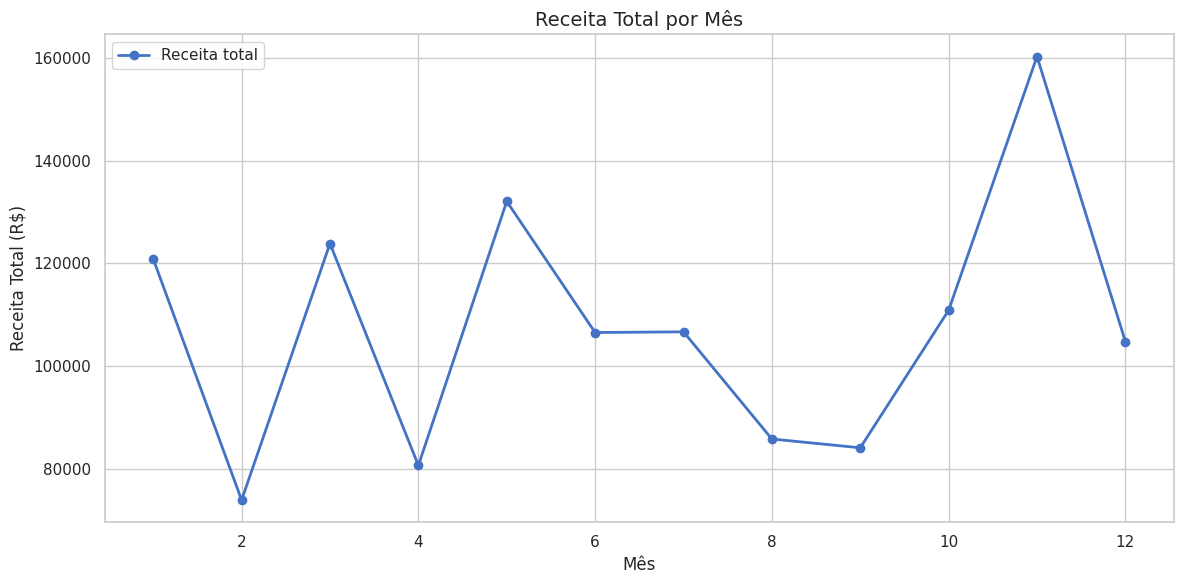

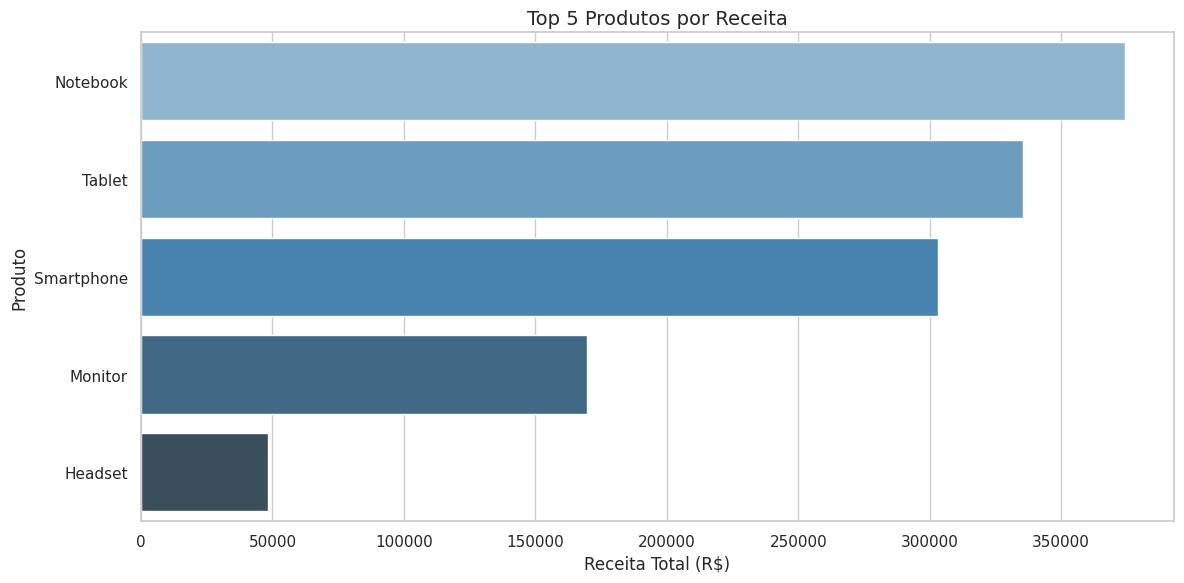

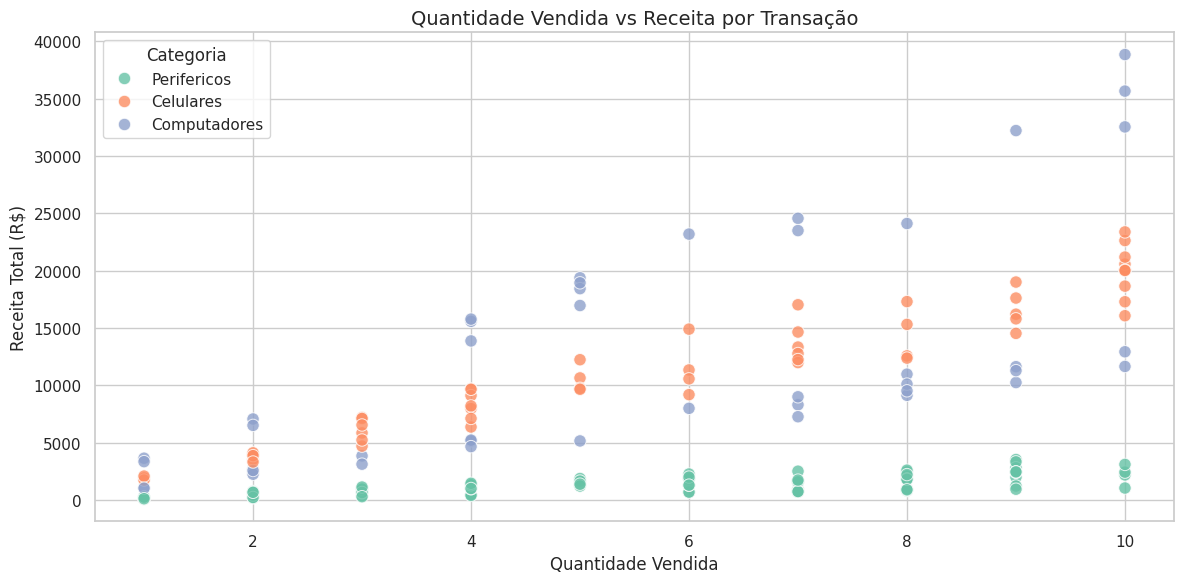

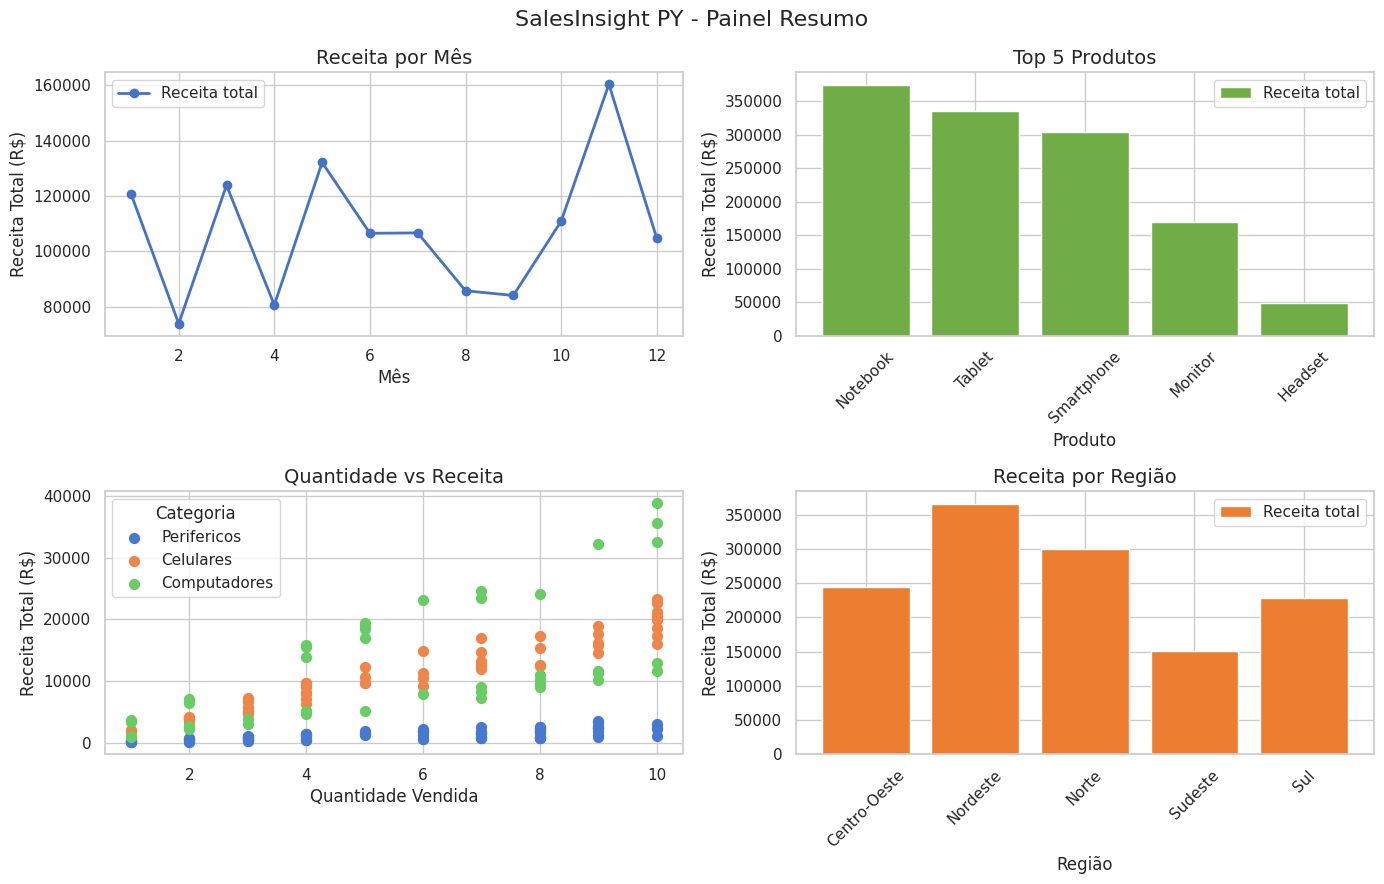


[Analisador] Gráficos gerados e exportados com sucesso.

=== EXPORTAÇÃO DOS RESULTADOS ===
Métricas por mês: outputs/metricas_por_mes.csv
Segmentação de clientes: outputs/segmentacao_clientes.csv
Estatísticas gerais: outputs/estatisticas_gerais.json

=== CONFERÊNCIA DO JSON ===
media: 7051.07
mediana: 3330.66
desvio_padrao: 7809.92
soma: 1290346.3
minimo: 104.19
maximo: 38833.2
quantidade_acima_media: 70.0

=== RESUMO DA ANÁLISE ===
Registros brutos: 200
Registros após limpeza: 183
Registros removidos: 17

Receita total: R$ 1290346.30
Receita média por transação: R$ 7051.07
Maior receita por transação: R$ 38833.20
Clientes analisados: 50

Distribuição por segmento:
segmento
Ouro      34
Prata     10
Bronze     6
Name: count, dtype: int64

[CONCLUÍDO] Fluxo finalizado com sucesso.


In [34]:
# RF11 – Executar o Fluxo Completo (Ponto de Entrada)

def main():
    """
    Executa o fluxo completo do SalesInsight PY.
    """

    print("=" * 60)
    print("   SALESINSIGHT PY - Análise de Dados de Vendas")
    print("=" * 60)

    if not os.path.exists("vendas.csv"):
        print("\nDataset não encontrado.")
        return

    analyzer = SalesDataAnalyzer(
        "vendas.csv"
    )

    analyzer.load()

    data_inspect(analyzer.raw_df)

    analyzer.clean()

    analyzer.transform()

    analyzer.analyze()

    analyzer.visualize()

    export_results(
        analyzer.metrics,
        analyzer.clients,
        analyzer.numpy_results
    )

    analyzer.summary()

    print(
        "\n[CONCLUÍDO] "
        "Fluxo finalizado com sucesso."
    )


if __name__ == "__main__":
    main()